In [46]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from bs4 import BeautifulSoup
import requests

First, I will scrap data from the website Every Noise at Once.

In [43]:
url = "https://www.everynoise.com/engenremap.html"

r = requests.get(url)
soup = BeautifulSoup(r.text, "html.parser")

genres = []

for tag in soup.find_all("div"):
    style = tag.get("style")

    if style and "color:" in style:
        genre = tag.text.strip().rstrip("»")

        color = style.split("color:")[1].split(";")[0]

        genres.append((genre, color))

In [44]:
print(genres[100])

('turkish pop', ' #a2880b')


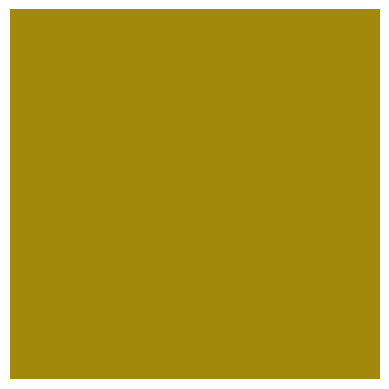

In [47]:
color = "#a2880b"

rgb = mcolors.to_rgb(color)
square = np.ones((100,100,3))*rgb

plt.imshow(square, cmap=None)
plt.gca().set_facecolor(color)
plt.axis("off")
plt.show()

In [17]:
img = Image.open("test.jpg").convert("RGB")
pixels = np.array(img)

In [18]:
print(np.shape(pixels))

(1999, 3554, 3)


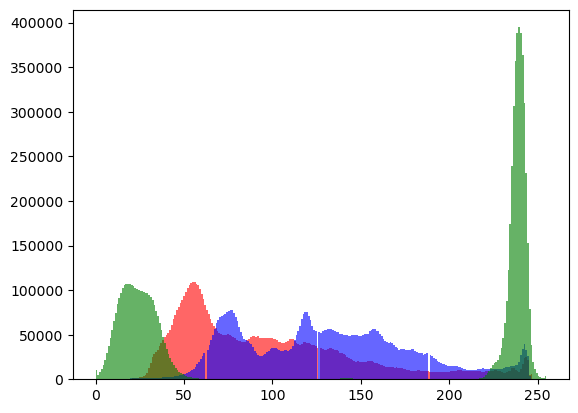

In [24]:
plt.hist(pixels[:,:,0].ravel(),bins = 256, color = 'red', alpha = 0.6)
plt.hist(pixels[:,:,1].ravel(),bins = 256, color = 'blue', alpha = 0.6)
plt.hist(pixels[:,:,2].ravel(),bins = 256, color = 'green', alpha = 0.6)
plt.show()